# Import
At first we need to import necessary modules and set-up the drive where we import the data from. Later when importing the Data you may need to adjust the path so it matches your drive.

In [4]:
#@title
#@Import packages
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.keras as k
import pandas as pd
#from google.colab import auth
#auth.authenticate_user()
#from oauth2client.client import GoogleCredentials
from google.colab import drive
drive.mount('/content/drive/')
%cd /content/drive/My\ Drive/Colab\ Notebooks/
#import gspread as gs
#import gspread_dataframe as gsd

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/drive/
/content/drive/My Drive/Colab Notebooks


In [5]:
%run '/content/drive/My Drive/Colab Notebooks/BA_functions.py'

In [6]:
Datas=binaryalldirections()

# 26th June: 3D PCA Autoencoder Hamming Distance

In [ ]:
model3d,encoder3d,decoder3d=hammodel3(10)

train=directpca(Datas[0],10)
training(model3d,0.0002,300,50,train,1,1,)

Model: "ae"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 10)]              0         
_________________________________________________________________
encoder (Model)              (None, 3)                 634       
_________________________________________________________________
Decoder (Model)              (None, 10)                798       
Total params: 1,432
Trainable params: 1,274
Non-trainable params: 158
_________________________________________________________________
Epoch 1/50
15/15 [==============================] - 0s 26ms/step - loss: 1.4310 - val_loss: 1.0147
Epoch 2/50
15/15 [==============================] - 0s 6ms/step - loss: 1.3753 - val_loss: 1.0124
Epoch 3/50
15/15 [==============================] - 0s 6ms/step - loss: 1.3489 - val_loss: 1.0149
Epoch 4/50
15/15 [==============================] - 0s 6ms/step - loss: 1.3187 - val_loss: 1.01

array([[ 1.33431194,  1.18092951,  0.60166517, ...,  0.48624343,
         2.29002573, -1.11637959],
       [-0.81209266,  0.84433751,  0.77876355, ..., -0.15069374,
        -0.99888588,  0.53904523],
       [-0.91311889, -0.04754365, -0.83948119, ...,  1.06876842,
        -0.16003305, -0.19581745],
       ...,
       [-0.25054551,  0.41190261, -0.62019532, ..., -1.66659759,
         1.16265269, -1.49108665],
       [ 0.13168361,  0.2816141 ,  0.34923587, ...,  0.16016249,
         1.30143715, -1.16413813],
       [ 2.58121629,  0.20809139, -1.07872587, ...,  1.39678293,
         0.42487137, -0.47419796]])

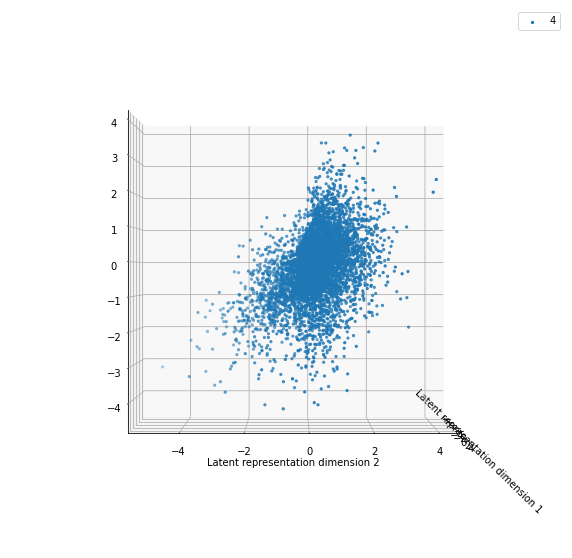

In [ ]:
#alldir=directpca(Datas,10)
latrepmulti3d(encoder3d,[train],['4','5','6','7'],0,0)

(5313, 10)


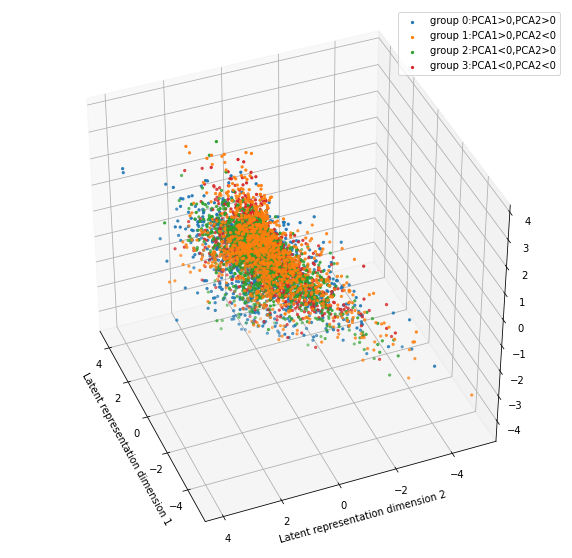

In [ ]:
groupsind=[[] for n in range(4)]
groups=[[] for n in range(4)]
newrep=train
print(np.shape(newrep))
for n in range(len(newrep)):
    dp=newrep[n]
    if dp[0]>0:
        if dp[1]>0:
            a=0
        else:
            a=1
    else:
        if dp[1]>0:
            a=2
        else:
            a=3
    groupsind[a].append(n)
    groups[a].append
#groups_=np.array(groups)
#print((groups[0]))
foo=latrepmulti3d(encoder3d,[newrep[groupsind[0]],newrep[groupsind[1]],
                     newrep[groupsind[2]],newrep[groupsind[3]]]
                     ,['group 0:PCA1>0,PCA2>0','group 1:PCA1>0,PCA2<0',
                       'group 2:PCA1<0,PCA2>0','group 3:PCA1<0,PCA2<0'],40,158)

# 27 June: Siamese for Hamming-Dist

In [ ]:
#Network:

def siamese(inputshape):
    #FIrst define twin part
    fullinput=k.Input((2,27,27))
    #print(np.shape(fullinput))
    #print(np.shape(fullinput[:,0]))
    model=k.Sequential()
    model.add(k.layers.Reshape((27,27,1),input_shape=inputshape))
    model.add(k.layers.Conv2D(32,(3,3),activation='relu'
                    ))
    #model.add(k.layers.MaxPooling2D())
    model.add(k.layers.Conv2D(64,(2,2),activation='relu'
                    ))
    model.add(k.layers.MaxPooling2D())
    model.add(k.layers.Conv2D(64,(2,2),activation='relu'
                    ))
    #model.add(k.layers.MaxPooling2D())
    model.add(k.layers.Conv2D(128,(3,3),activation='relu'
                    ))
    #model.add(k.layers.MaxPooling2D())
    model.add(k.layers.Flatten())
    model.add(k.layers.Dense(256,activation='sigmoid',
                             ))

    enc_l=model(fullinput[:,0])
    enc_r=model(fullinput[:,1])


    #customized layer
    clayer=k.layers.Lambda(lambda tensors: k.backend.abs(tensors[0]-tensors[1]))
    c_distance=clayer([enc_l,enc_r])

    #dense layer for similarity score
    prediction=k.layers.Dense(1,activation='sigmoid')(c_distance)

    siam=k.Model(inputs=fullinput,outputs=prediction)
    #model.summary()
    return siam

For each ctcf sample we create a number (samplespersamle) of samples. One of these pairs is the sample with itself, with a labelled value of 1, the other 4 are random other ctcf samples, labelled 0.

In [ ]:
#create pairs
def createpairs(Dataset,samplespersample):
    np.random.seed(123)
    output1=[[[],[]]for n in range(len(Dataset)*samplespersample)]
    output2=[[] for n in range(len(Dataset)*samplespersample)]
    for n in range(len(Dataset)):
        m=n*samplespersample
        output1[m][0]=Dataset[n]
        output1[m][1]=Dataset[n]
        output2[m]=0
        for nn in range(1,samplespersample):
            m=n*samplespersample+nn
            rand_index=np.random.randint(len(Dataset))
            while rand_index==nn:
                rand_index=np.random.randint(len(Dataset))
            output1[m][0]=Dataset[n]
            output1[m][1]=Dataset[rand_index]
            output2[m]=1  
    return np.array(output1),np.array(output2)
#create pairs
def createpairs2(Dataset1,Dataset2,samplespersample):
    np.random.seed(23)
    output1=[[[],[]]for n in range(len(Dataset1)*samplespersample)]
    output2=[[] for n in range(len(Dataset1)*samplespersample)]
    for n in range(len(Dataset1)):
        m=n*samplespersample
        output1[m][0]=Dataset1[n]
        output1[m][1]=Dataset2[n]
        output2[m]=0
        for nn in range(1,samplespersample):
            m=n*samplespersample+nn
            rand_index=np.random.randint(len(Dataset1))
            while rand_index==nn:
                rand_index=np.random.randint(len(Dataset1))
            output1[m][0]=Dataset1[n]
            output1[m][1]=Dataset2[rand_index]
            output2[m]=1  
    return np.array(output1),np.array(output2)
def traininglabels(model, lra,bs,ep,dataset,labels,reset,vb):
    if reset==1:
        reset_weights(model)
    opti=k.optimizers.Adamax(lr=lra)
    model.compile(loss="mse",optimizer=opti)
    history=model.fit(dataset,labels,batch_size=bs,epochs=ep,shuffle=True,validation_split=0.2,verbose=vb)
    ep=history.epoch
    h=pd.DataFrame(history.history)


In [ ]:
ham=n_analysis(Datas[0])
test,labels=createpairs(ham,5)

In [ ]:
siam=siamese((27,27))
#print(np.shape(np.array(test)))
traininglabels(siam,0.0006,100,10,np.array(test),np.array(labels),1,1)

(None, 2, 27, 27)
(None, 27, 27)
Epoch 1/10
213/213 [==============================] - 101s 472ms/step - loss: 0.0636 - val_loss: 0.0490
Epoch 2/10
213/213 [==============================] - 103s 486ms/step - loss: 0.0478 - val_loss: 0.0464
Epoch 3/10
213/213 [==============================] - 100s 467ms/step - loss: 0.0450 - val_loss: 0.0434
Epoch 4/10
213/213 [==============================] - 100s 468ms/step - loss: 0.0418 - val_loss: 0.0400
Epoch 5/10
213/213 [==============================] - 100s 467ms/step - loss: 0.0383 - val_loss: 0.0365
Epoch 6/10
213/213 [==============================] - 100s 468ms/step - loss: 0.0348 - val_loss: 0.0330
Epoch 7/10
213/213 [==============================] - 100s 468ms/step - loss: 0.0314 - val_loss: 0.0298
Epoch 8/10
213/213 [==============================] - 103s 485ms/step - loss: 0.0283 - val_loss: 0.0267
Epoch 9/10
213/213 [==============================] - 99s 466ms/step - loss: 0.0253 - val_loss: 0.0239
Epoch 10/10
213/213 [===========

Base index 5


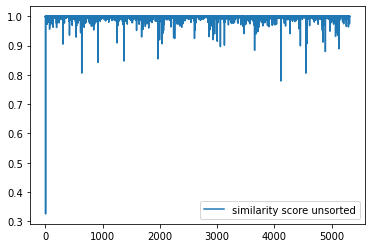

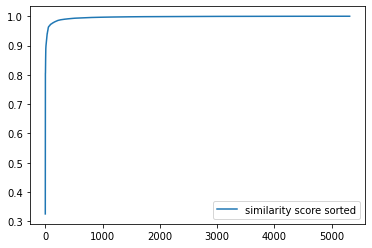

Base index 6


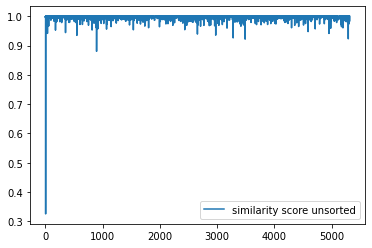

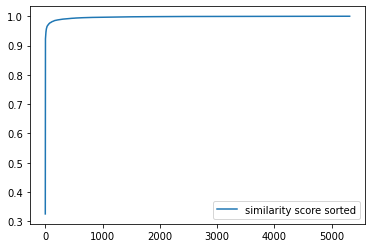

Base index 3000


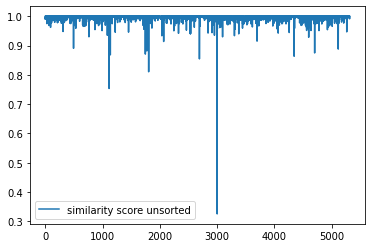

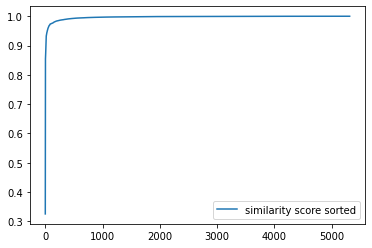

In [ ]:
a=similarityplot(siam,ham,5)
a=similarityplot(siam,ham,6)
a=similarityplot(siam,ham,3000)

## refining the pair creation
In the first step we just labeled the same images with 0, but as we see above the distinction is really strong and we want to make it "softer". The first approach is to add random noise to ALL the entries and then train the model with those.



In [ ]:
print(np.shape(ham))
def addnoise(hamdata,sigma):
    np.random.seed(264)
    noisedata=np.random.normal(scale=sigma,size=(len(hamdata),len(hamdata[0]),len(hamdata[0][0])))
    dataplusnoise=np.add(hamdata,noisedata)
    return(dataplusnoise)

hamnoise=addnoise(ham,0.2)
train2,labels2=createpairs2(ham,hamnoise,5)

(5313, 27, 27)


In [ ]:
print(np.shape(train2))
print(np.shape(labels2))
print(train2[0][0])
print(labels2[0])

(26565, 2, 27, 27)
(26565,)


In [ ]:
siamnoise=siamese((27,27))
traininglabels(siamnoise,0.0006,3000,2,train2[3000:],labels2[3000:],1,1)

Epoch 1/2
7/7 [==============================] - 68s 10s/step - loss: 0.2437 - val_loss: 0.2248
Epoch 2/2
7/7 [==============================] - 68s 10s/step - loss: 0.2149 - val_loss: 0.2041


Base index 0


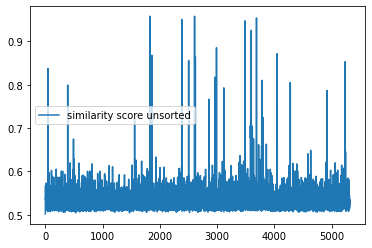

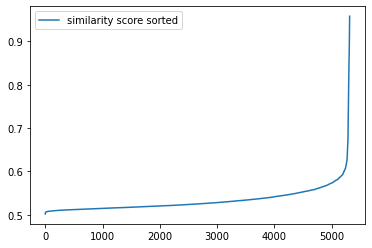

Base index 1


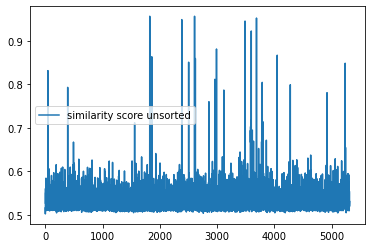

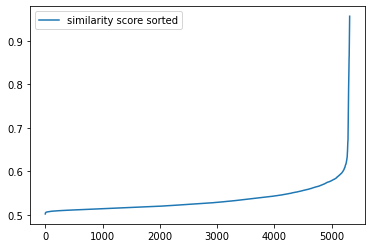

Base index 2


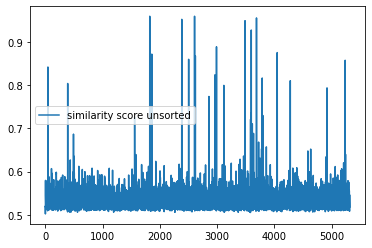

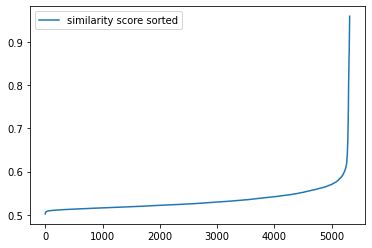

Base index 3


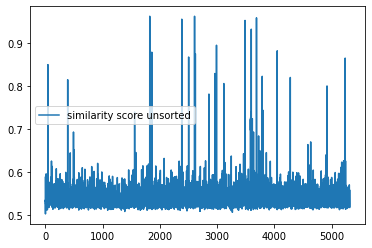

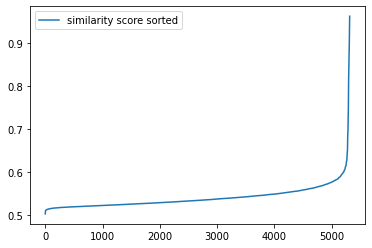

Base index 4


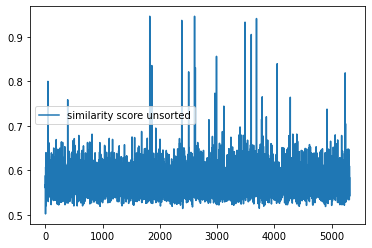

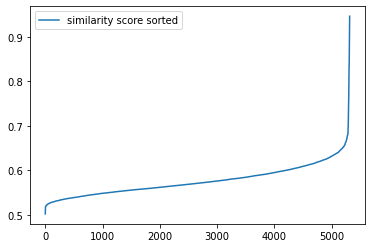

In [ ]:
for n in range(5):
    _=similarityplot(siamnoise,ham,n)